# Linear Regression

Loads the preprocessed Model 1 (demographic + access) and Model 2 (+ clinical) feature matrices produced by `scripts/preprocess.py`. See `MODELING.md` for the full implementation guide.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

m1 = pd.read_csv("../data/processed/nhamcs_model1_encoded.csv")
m2 = pd.read_csv("../data/processed/nhamcs_model2_encoded.csv")


In [2]:
#demographics + access
m1.head()

,age_years,survey_year,wait_time_min,log_wait_time,sex_Male,race_American Indian/Alaska Native Only,race_Asian Only,race_Black/African American Only,race_More than one race reported,race_Native Hawaiian/Oth Pac Isl Only,...,payment_type_Medicare,payment_type_No charge/Charity,payment_type_Other,payment_type_Self-pay,payment_type_Unknown,payment_type_Worker's compensation,arrival_mode_Ambulance,arrival_mode_Personal transportation,arrival_mode_Public service (nonambulance),arrival_mode_Unknown
0,24.0,2007,255.0,5.545177,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
1,30.0,2007,87.0,4.477337,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
2,24.0,2007,5.0,1.791759,0,0,0,1,0,0,...,0,0,0,1,0,0,0,1,0,0
3,62.0,2007,75.0,4.330733,1,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
4,34.0,2007,95.0,4.564348,1,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0


In [3]:
#demographics + access + clinical
m2.tail()

,age_years,survey_year,wait_time_min,log_wait_time,pulse,systolic_bp,pulse_missing,systolic_bp_missing,sex_Male,race_American Indian/Alaska Native Only,...,payment_type_Worker's compensation,arrival_mode_Ambulance,arrival_mode_Personal transportation,arrival_mode_Public service (nonambulance),arrival_mode_Unknown,triage_acuity_High,triage_acuity_Low,triage_acuity_Unknown,seen_72h_Unknown,seen_72h_Yes
329244,56.0,2022,13.0,2.639057,84.0,172.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
329245,12.0,2022,45.0,3.828641,90.0,110.0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
329246,44.0,2022,105.0,4.663439,81.0,124.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
329247,31.0,2022,16.0,2.833213,98.0,115.0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
329248,39.0,2022,6.0,1.945910,95.0,133.0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0


## EDA on the modeling dataset

`m1`/`m2` are one-hot encoded, which makes them hard to explore directly (e.g. `race` is
spread across 7 dummy columns with the reference category implicit as all-zero). The rest
of this EDA uses `nhamcs_cleaned_2007_2022.csv` — the same rows, pre-encoding, with
human-readable category labels — then comes back to `m1`/`m2` for the encoding-specific
checks (missingness after encoding, multicollinearity).

In [4]:
df = pd.read_csv("../data/processed/nhamcs_cleaned_2007_2022.csv")
print(f"Cleaned dataset: {df.shape[0]:,} rows x {df.shape[1]} cols")
df.dtypes

Cleaned dataset: 332,322 rows x 25 cols


wait_time_min          float64
age_years              float64
sex                        str
race                       str
ethnicity                  str
triage_immediacy           str
arrival_mode               str
payment_type               str
admit_hospital             str
admit_observation          str
length_of_visit_min    float64
pulse                  float64
systolic_bp            float64
pain_scale             float64
seen_72h                   str
visit_month                str
visit_day_of_week          str
residence                  str
survey_year              int64
wait_time_clamped      float64
log_wait_time          float64
triage_acuity              str
pulse_missing            int64
systolic_bp_missing      int64
seen_72h_missing         int64
dtype: object

Target variable: `wait_time_min` / `log_wait_time`

In [5]:
from scipy.stats import skew

display(df[["wait_time_min", "log_wait_time"]].describe())
print(f"Skewness — wait_time_min: {skew(df['wait_time_min'].dropna()):.2f}")
print(f"Skewness — log_wait_time: {skew(df['log_wait_time'].dropna()):.2f}")

,wait_time_min,log_wait_time
count,332322.000000,332322.000000
mean,45.538189,3.087448
std,74.682867,1.293796
min,0.000000,0.000000
25%,9.000000,2.302585
50%,23.000000,3.178054
75%,53.000000,3.988984
max,1440.000000,6.175867


Skewness — wait_time_min: 5.89
Skewness — log_wait_time: -0.33


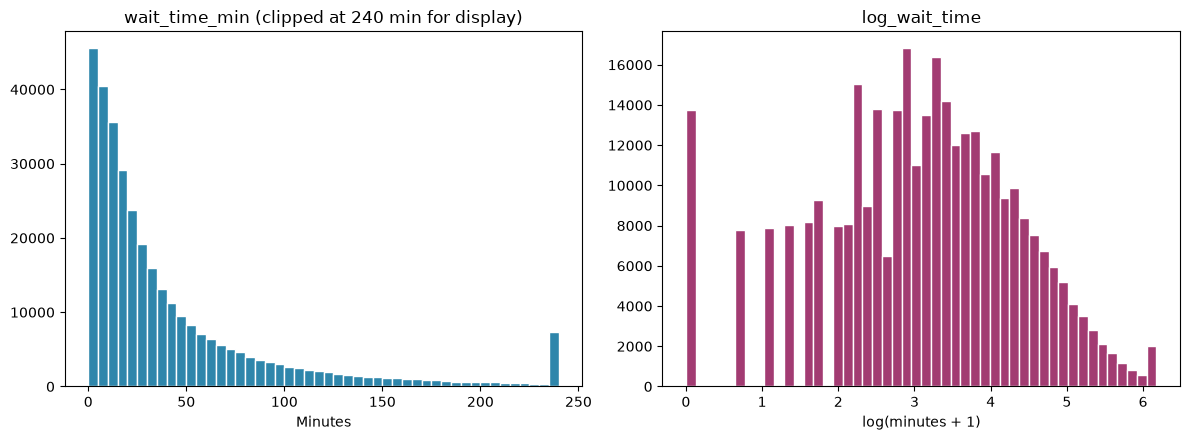

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(df["wait_time_min"].clip(upper=240), bins=48, color="#2E86AB", edgecolor="white")
axes[0].set_title("wait_time_min (clipped at 240 min for display)")
axes[0].set_xlabel("Minutes")
axes[1].hist(df["log_wait_time"], bins=48, color="#A23B72", edgecolor="white")
axes[1].set_title("log_wait_time")
axes[1].set_xlabel("log(minutes + 1)")
plt.tight_layout()
plt.show()

**Findings — target variable**

- `wait_time_min` is heavily right-skewed (skewness = 5.89): mean 45.5 min is nearly double the median (23 min), and the tail runs out to 1,440 min.
- `log_wait_time` brings skewness down to -0.33 — close to symmetric — confirming the log transform planned in `MODELING.md` is the right choice for OLS rather than an arbitrary preference.
- The cleaned file (used here) keeps the full range; the encoded model files (`m1`/`m2`) clamp `wait_time_min` to 480 before saving, so the 1,440 max only appears here.

Missingness in raw (pre-encoding) fields

In [7]:
raw_cols = [
    "pulse", "systolic_bp", "race", "ethnicity", "payment_type",
    "triage_immediacy", "triage_acuity", "seen_72h", "residence", "arrival_mode",
]
missing_pct = df[raw_cols].isna().mean().mul(100).round(2).sort_values(ascending=False)
missing_pct.to_frame("pct_missing")

,pct_missing
triage_acuity,22.80
triage_immediacy,16.85
race,15.02
seen_72h,11.40
payment_type,7.30
arrival_mode,3.64
residence,2.98
pulse,0.00
systolic_bp,0.00
ethnicity,0.00


**Findings — missingness**

- Triage fields are missing the most: `triage_acuity` 22.8%, `triage_immediacy` 16.9% — because not every NHAMCS facility/year collected a triage score, not because of data entry errors.
- `race` is missing 15.0%, `seen_72h` 11.4%, `payment_type` 7.3%, `arrival_mode` 3.6%, `residence` 3.0%.
- `pulse`, `systolic_bp`, and `ethnicity` show 0% missing **in this file** — vitals were already median-imputed by `engineer_features()` before saving; their original missingness (5.4% for pulse, 10.3% for systolic BP) is preserved separately via the `pulse_missing`/`systolic_bp_missing` indicator flags instead.
- All of this missingness is routed into an explicit `_Unknown` one-hot category per field (confirmed in section 8) rather than silently defaulting to the reference group — the encoding design already accounts for this.

Numeric feature distributions (age, vitals)

,age_years,pulse,systolic_bp
count,330887.000000,332322.000000,332322.000000
mean,37.820511,91.208936,133.147839
std,23.982236,22.442213,22.476562
min,0.500000,1.000000,2.000000
25%,19.000000,77.000000,119.000000
50%,35.000000,88.000000,131.000000
75%,55.000000,101.000000,144.000000
max,99.000000,244.000000,290.000000


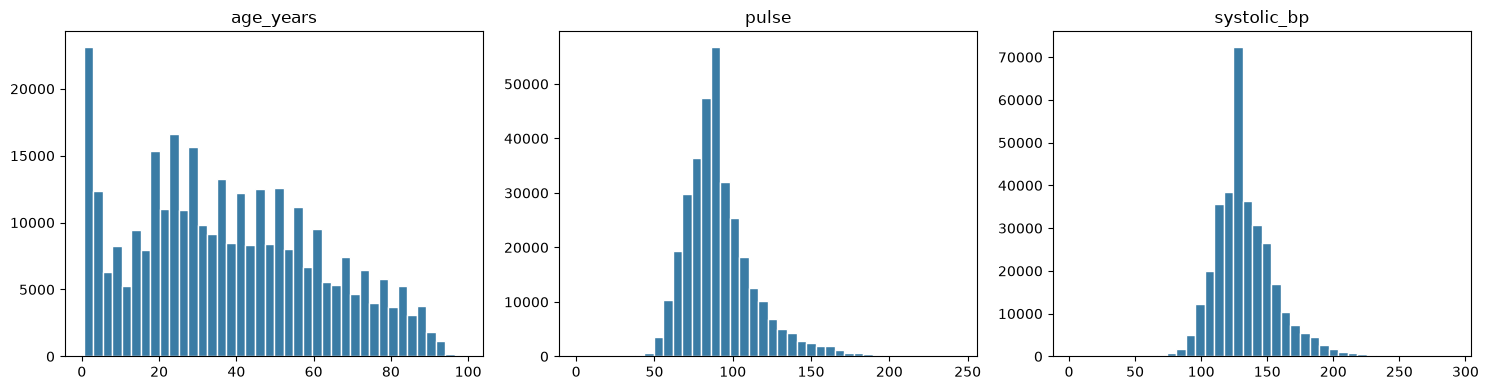

In [8]:
numeric_cols = ["age_years", "pulse", "systolic_bp"]
display(df[numeric_cols].describe())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    ax.hist(df[col].dropna(), bins=40, color="#3A7CA5", edgecolor="white")
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Findings — numeric features**

- `age_years`: mean 37.8, median 35, range 0.5–99 (0.5 = the "under 1 year" category midpoint).
- `pulse`: mean 91.2, median 88 — the histogram shows a visible spike exactly at 88, the imputed value for the 5.4% of rows that were originally missing.
- `systolic_bp`: mean 133.1, median 131 — same imputation-spike pattern, for the 10.3% originally missing.
- A handful of physiologically implausible vitals remain: 32 rows with pulse ≤ 5 bpm and 3 rows with systolic BP ≤ 10 mmHg. These weren't caught by the `== 0` missing-value rule in `preprocess.py`. Negligible in count (<0.02% of rows) — not worth a filtering pass, but worth knowing about if a residual/outlier plot looks odd later.

Categorical feature balance

In [9]:
cat_cols = [
    "race", "ethnicity", "sex", "payment_type", "arrival_mode",
    "residence", "triage_acuity", "visit_day_of_week", "visit_month",
]
for col in cat_cols:
    print(f"\n=== {col} ===")
    print((df[col].value_counts(normalize=True, dropna=False) * 100).round(1))


=== race ===
race
White Only                            60.1
Black/African American Only           21.2
NaN                                   15.0
Asian Only                             2.1
American Indian/Alaska Native Only     0.6
More than one race reported            0.5
Native Hawaiian/Oth Pac Isl Only       0.4
Name: proportion, dtype: float64

=== ethnicity ===
ethnicity
Not Hispanic or Latino    84.5
Hispanic or Latino        15.5
Name: proportion, dtype: float64

=== sex ===
sex
Female    54.4
Male      45.6
Name: proportion, dtype: float64

=== payment_type ===
payment_type
Medicaid/CHIP            30.4
Private insurance        28.5
Medicare                 18.4
Self-pay                 11.2
NaN                       7.3
Other                     2.5
Worker's compensation     0.9
No charge/Charity         0.8
Name: proportion, dtype: float64

=== arrival_mode ===
arrival_mode
Walk-in/Other                    67.0
Ambulance                        16.6
Personal transportation 

**Findings — categorical balance**

- `race`: White 60.1%, Black 21.2%, missing 15.0%, Asian 2.1% — and three categories under 1%: American Indian/Alaska Native (0.6%, n=2,112), multiracial (0.5%, n=1,678), Native Hawaiian/Pacific Islander (0.4%, n=1,493). Coefficients for these small groups will have wide confidence intervals — flag this when interpreting significance.
- `payment_type`: Medicaid/CHIP (30.4%) and Private insurance (28.5%) are close to tied for the largest group, Medicare 18.4%, Self-pay 11.2%, missing 7.3%. Other/Worker's comp/No-charge are all under 3%.
- `arrival_mode`: Walk-in/Other dominates at 67.0%; Public service (non-ambulance) is only 0.5% (n=1,624).
- `residence`: Private residence is 92.7% of all rows — it's the reference category, so every residence coefficient is estimated against an overwhelming majority baseline from small subgroups (nursing home 1.9%, homeless combined ~1.0%).
- `triage_acuity`: Medium 63.1%, missing 22.8% (routed to `Unknown`), High 9.5%, Low 4.6%.
- `visit_day_of_week` (13.7–15.8%) and `visit_month` (7.3–9.0%) are both close to uniform — no material seasonal or weekday sampling imbalance to worry about.

### 5. Bivariate: mean wait time by group

A first look at the equity question, before any modeling controls for confounders.

In [10]:
group_cols = ["race", "payment_type", "arrival_mode", "triage_acuity"]
for col in group_cols:
    g = df.groupby(col, observed=True)["wait_time_min"].agg(["mean", "count"]).sort_values("mean")
    print(f"\n=== {col} ===")
    print(g.round(1))


=== race ===
                                    mean   count
race                                            
Native Hawaiian/Oth Pac Isl Only    41.0    1493
White Only                          42.1  199834
Asian Only                          44.6    6973
American Indian/Alaska Native Only  49.7    2112
Black/African American Only         55.4   70320
More than one race reported         56.1    1678

=== payment_type ===
                       mean   count
payment_type                       
Worker's compensation  39.6    2908
Medicare               41.2   61302
Private insurance      42.5   94763
Medicaid/CHIP          46.7  101136
Other                  49.1    8227
Self-pay               54.0   37246
No charge/Charity      64.9    2495

=== arrival_mode ===
                               mean   count
arrival_mode                               
Ambulance                      36.7   55081
Walk-in/Other                  44.7  222790
Personal transportation        58.3   40715
Public

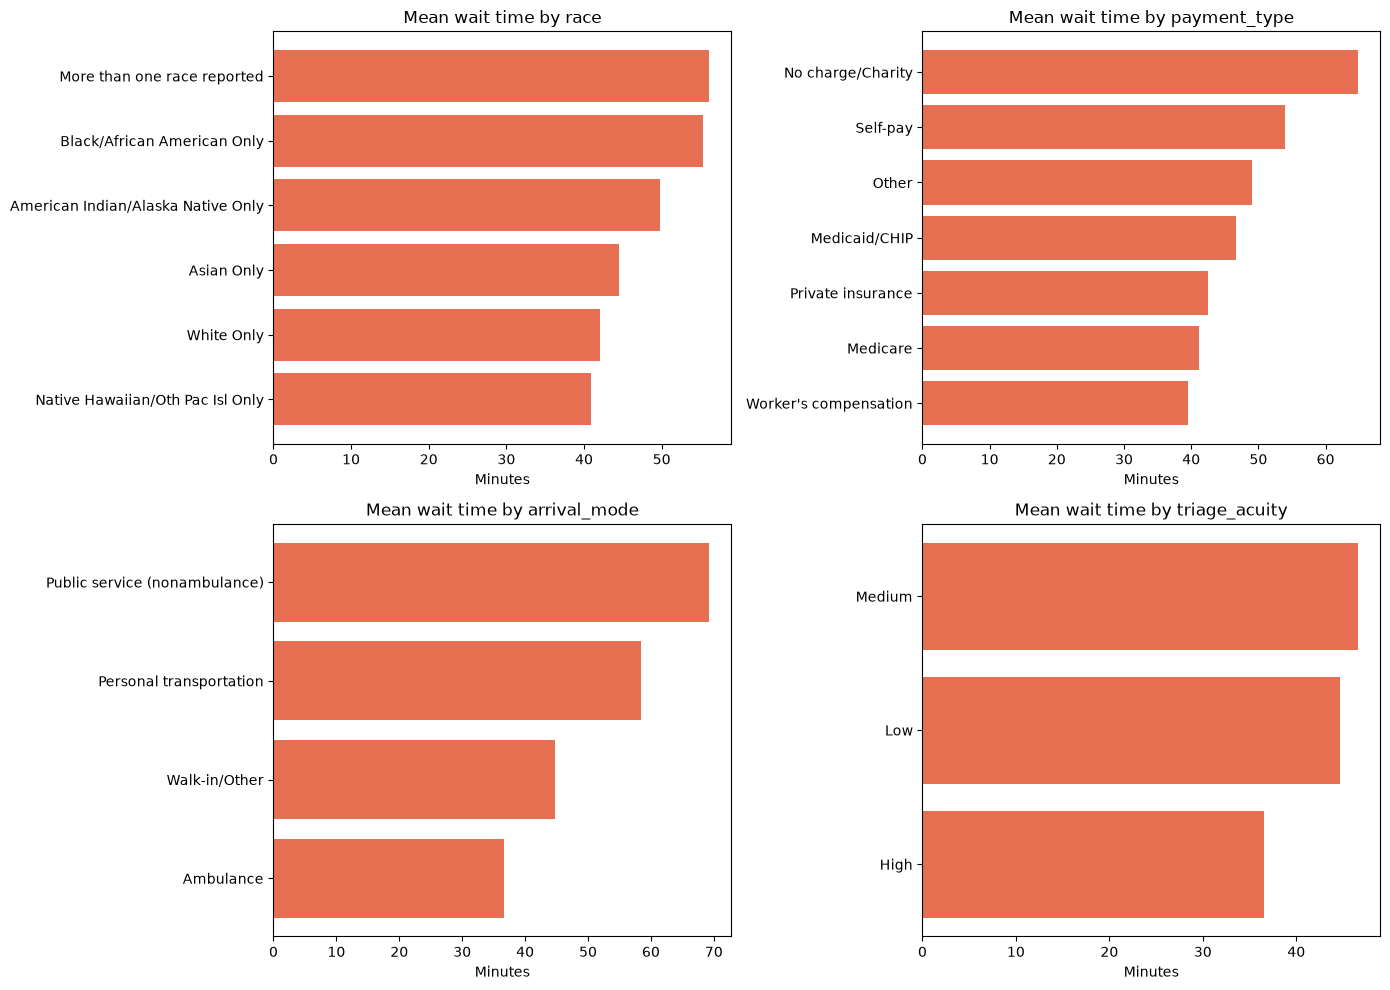

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flat, group_cols):
    means = df.groupby(col, observed=True)["wait_time_min"].mean().sort_values()
    ax.barh(means.index, means.values, color="#E76F51")
    ax.set_title(f"Mean wait time by {col}")
    ax.set_xlabel("Minutes")
plt.tight_layout()
plt.show()

**Findings — bivariate group differences** *(raw, unadjusted — this is exactly what Model 1 vs Model 2 will test for a clinical explanation)*

- **Race:** Black patients wait 55.4 min on average vs. 42.1 min for White patients (n=70,320 vs. 199,834) — a 13.3-minute raw gap on the two largest groups. Multiracial (56.1 min) and American Indian/Alaska Native (49.7 min) patients also wait longer than White patients, though on much smaller samples.
- **Payment:** No charge/Charity patients wait longest (64.9 min, n=2,495), then Self-pay (54.0 min). Medicaid/CHIP (46.7 min) exceeds both Private insurance (42.5 min) and Medicare (41.2 min, shortest of the common payers).
- **Arrival mode:** Ambulance patients wait shortest (36.7 min) — expected, since they arrive with documented acuity. Personal transportation (58.3 min) and non-ambulance public service (69.3 min, n=1,624) wait far longer than walk-in (44.7 min).
- **Triage acuity — the key non-clinical-driver finding:** High-acuity patients wait shortest (36.5 min), consistent with sicker patients being prioritized. But Medium-acuity patients wait *longer* (46.6 min) than Low-acuity patients (44.7 min) — a non-monotonic relationship. Triage urgency alone does not cleanly explain queue position past the "High" tier, which is exactly the gap the demographic/access variables in Model 1 vs. Model 2 are positioned to explain (or fail to).

### 6. Correlation among numeric predictors

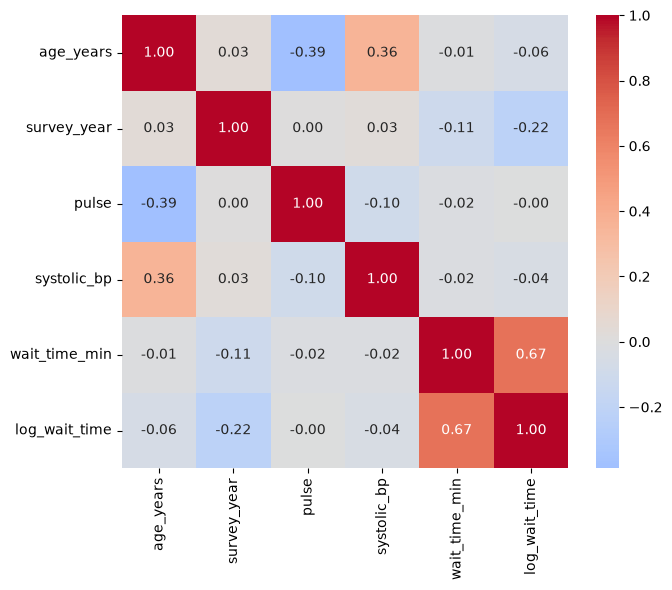

In [12]:
import seaborn as sns

num_for_corr = ["age_years", "survey_year", "pulse", "systolic_bp", "wait_time_min", "log_wait_time"]
corr = df[num_for_corr].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
plt.tight_layout()
plt.show()

Numeric correlations

- Every numeric predictor correlates weakly with wait time on its own: `age_years` (r=-0.01), `pulse` (r=-0.02), `systolic_bp` (r=-0.02) with `wait_time_min`. None is individually informative.
- `survey_year` has the strongest — still weak — relationship: r=-0.11 with `wait_time_min` and r=-0.22 with `log_wait_time`. Wait times trended down over 2007–2022, which is why `survey_year` is kept as a control in both models rather than treated as noise.
- `pulse` and `age_years` correlate at r=-0.39 (older patients tend to have lower resting heart rate — physiologically expected). This is a real but moderate correlation, not a collinearity concern (confirmed by VIF below).
- `log_wait_time` correlates 0.67 with `wait_time_min`, which is expected since it's a monotonic transform of the same quantity, not an independent signal.

Multicollinearity check on the encoded Model 2 matrix (VIF)

One-hot encoding many categorical families can introduce collinearity even after dropping a
reference level per family. Computed on a 20,000-row sample of `m2` for speed — VIF measures
correlation structure, which a large random sample estimates just as well as the full data.

In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

feature_cols = [c for c in m2.columns if c not in ("wait_time_min", "log_wait_time")]
X_vif = m2[feature_cols].sample(20000, random_state=42).astype(float)
X_vif = sm.add_constant(X_vif)

vif = pd.Series(
    [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
    index=X_vif.columns,
).drop("const").sort_values(ascending=False)
vif.head(15)

age_years                    2.381559
payment_type_Medicare        1.897770
visit_month_January          1.895167
visit_month_November         1.882114
visit_month_August           1.853625
visit_month_May              1.848451
visit_month_September        1.833167
visit_month_March            1.829471
visit_month_June             1.826219
visit_month_April            1.824066
visit_month_October          1.798372
visit_month_February         1.783455
visit_day_of_week_Monday     1.775772
visit_month_December         1.742227
visit_day_of_week_Tuesday    1.740329
dtype: float64

**Findings — multicollinearity (action item before fitting Model 2)**

- `seen_72h_Unknown` and `seen_72h_missing` both return **infinite VIF**, with statsmodels raising a divide-by-zero warning. Verified directly: the two columns have a Pearson correlation of exactly **1.0** across all 37,501 rows where either is 1 — they are perfect duplicates.
- Root cause: both are derived from the *same* missingness in the raw `seen_72h` field. `seen_72h_missing` is the indicator flag added in `engineer_features()`, and `seen_72h_Unknown` is the one-hot level created for the same NaNs during encoding (`_one_hot`'s "give missing values their own Unknown category" logic). Nothing distinguishes them.
- **This will break OLS on Model 2 as currently encoded** — `sm.OLS` will hit a singular design matrix (or silently drop one column and produce an uninterpretable split coefficient). Before Step 3 in `MODELING.md`, drop one of the two columns from Model 2's feature set — recommend dropping `seen_72h_missing`, since `seen_72h_Unknown` already carries the same information consistently with how every other categorical's missingness is handled (race, payment, triage, etc. don't get a separate `_missing` column on top of their `_Unknown` dummy).
- Everything else is well-conditioned: the next-highest VIF is `age_years` at 2.38, and all one-hot dummies (month, day-of-week, payment type) sit between 1.7–1.9 — comfortably under the conventional VIF > 5–10 concern threshold. No other collinearity issues found.

Missingness after encoding

`m1`/`m2` should have **zero** missing values — every categorical NaN was routed into its own
`_Unknown` dummy column during encoding rather than silently becoming the reference category.

In [14]:
print(f"m1 total missing cells: {m1.isna().sum().sum()}")
print(f"m2 total missing cells: {m2.isna().sum().sum()}")

m1 total missing cells: 0
m2 total missing cells: 0


## Summary of EDA findings

1. **Log transform is empirically justified**, not just assumed: raw wait time skew 5.89 → 
   `log_wait_time` skew -0.33.
2. **Missingness is substantial for a few fields** (triage 17–23%, race 15%, seen_72h 11%, 
   payment 7%) but is handled correctly — routed to an explicit `Unknown` dummy, confirmed 
   zero missing cells in both `m1` and `m2`.
3. **Small-n categories will have noisy coefficients**: American Indian/Alaska Native (n=2,112), 
   multiracial (n=1,678), Native Hawaiian/Pacific Islander (n=1,493) in race; Worker's comp, 
   No-charge in payment; Public service in arrival mode. Report these with wide confidence 
   intervals in mind, don't over-read significance.
4. **Raw group differences already visible before any controls** — this is the equity signal 
   Model 1 vs. Model 2 exists to test: Black patients wait ~13 min longer than White patients 
   on average; non-ambulance arrivals wait much longer than ambulance; Medicaid/self-pay/no-charge 
   patients wait longer than Medicare/private insurance.
5. **Triage acuity is not a clean linear predictor of wait time** — High is fastest, but Medium 
   is slower than Low. Clinical urgency alone doesn't explain queue position, which is exactly 
   why the demographic/access comparison in Model 2 is interesting rather than a foregone conclusion.
6. **Numeric predictors are individually weak** (|r| < 0.4 among themselves, |r| < 0.12 with wait 
   time) — no single strong numeric driver; `survey_year`'s downward trend is the most notable 
   and is retained as a control in both models.
7. **Action item found and must be fixed before modeling:** `seen_72h_missing` and 
   `seen_72h_Unknown` are perfectly collinear (r=1.0, infinite VIF) in the Model 2 matrix — drop 
   one before fitting OLS, or `statsmodels` will hit a singular design matrix. No other 
   multicollinearity concerns (next-highest VIF is 2.38).
8. **Minor data-quality note:** a handful of physiologically implausible vitals remain 
   (pulse ≤ 5 in 32 rows, systolic BP ≤ 10 in 3 rows) — negligible in count, not worth filtering 
   given the scale of the dataset.

## Modeling — Linear Regression (OLS)

`seen_72h_missing` was dropped from Model 2 in `scripts/preprocess.py` (it was perfectly
collinear with `seen_72h_Unknown` — see the VIF finding above) and the processed CSVs were
regenerated. Model 2 is now 56 cols (54 features + 2 targets) instead of 57. Reloading `m1`/`m2`
picks up the fix automatically since they're read fresh at the top of this notebook.

Following `MODELING.md`: split → scale numeric columns (fit on train only) → fit OLS on Model 1
and Model 2 → compare demographic/access coefficients between the two → get HC3-robust
standard errors for inference.

In [15]:
from sklearn.model_selection import train_test_split

TARGET = "log_wait_time"
DROP = ["wait_time_min", "log_wait_time"]

X1 = m1.drop(columns=DROP)
X2 = m2.drop(columns=DROP)
y = m1[TARGET]  # same rows in both files, so y is identical

X1_train, X1_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42)
X2_train, X2_test, _, _ = train_test_split(X2, y, test_size=0.2, random_state=42)

print(f"Model 1: X_train {X1_train.shape}, X_test {X1_test.shape}")
print(f"Model 2: X_train {X2_train.shape}, X_test {X2_test.shape}")

Model 1: X_train (263399, 45), X_test (65850, 45)
Model 2: X_train (263399, 54), X_test (65850, 54)


In [16]:
from sklearn.preprocessing import StandardScaler

NUMERIC = ["age_years", "survey_year"]
NUMERIC_M2 = ["age_years", "survey_year", "pulse", "systolic_bp"]

X1_train, X1_test = X1_train.copy(), X1_test.copy()
X2_train, X2_test = X2_train.copy(), X2_test.copy()

# Fit the scaler on the training split only — fitting on the full dataset
# before splitting would leak test-set information into the training features.
scaler1 = StandardScaler()
X1_train[NUMERIC] = scaler1.fit_transform(X1_train[NUMERIC])
X1_test[NUMERIC] = scaler1.transform(X1_test[NUMERIC])

scaler2 = StandardScaler()
X2_train[NUMERIC_M2] = scaler2.fit_transform(X2_train[NUMERIC_M2])
X2_test[NUMERIC_M2] = scaler2.transform(X2_test[NUMERIC_M2])

### Fit OLS and evaluate

R² in the 0.05–0.20 range is expected for this outcome (see `MODELING.md`) — individual-level
NHAMCS fields don't capture hospital-level drivers of wait time (staffing, bed availability).
The research value is in the coefficients, not predictive accuracy.

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error


def evaluate(model, X_test, y_test, label):
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae_log = mean_absolute_error(y_test, preds)
    # Back-transform to minutes for interpretability
    mae_min = mean_absolute_error(np.expm1(y_test), np.expm1(preds))
    print(f"{label}: R2={r2:.4f}  MAE(log)={mae_log:.4f}  MAE(min)={mae_min:.1f}")
    return preds


lr1 = LinearRegression().fit(X1_train, y_train)
lr2 = LinearRegression().fit(X2_train, y_train)

_ = evaluate(lr1, X1_test, y_test, "Linear Regression — Model 1")
_ = evaluate(lr2, X2_test, y_test, "Linear Regression — Model 2")

Linear Regression — Model 1: R2=0.0744  MAE(log)=0.9677  MAE(min)=31.5
Linear Regression — Model 2: R2=0.0785  MAE(log)=0.9658  MAE(min)=31.4


**Findings — model fit**

- Model 1 (demographic + access): R² = 0.074, MAE = 31.5 min.
- Model 2 (+ clinical): R² = 0.079, MAE = 31.4 min.
- Adding triage acuity, pulse, systolic BP, and prior-visit flags improves R² by only **+0.004** 
  and MAE by 0.1 min. Clinical variables, as recorded in NHAMCS, add almost nothing to 
  predictive power once demographic and access variables are already in the model — consistent 
  with the weak numeric correlations and non-monotonic triage effect found in the EDA. Both R² 
  values are in the expected 0.05–0.20 range for this outcome; low predictive power doesn't 
  undermine the coefficients below, which is the actual research target.

### Model evaluation — results and diagnostics

A confusion matrix doesn't apply here: this is a regression problem predicting a continuous value (`log_wait_time`), not a classification problem with discrete predicted classes. The regression equivalents are a metrics table plus diagnostic plots — actual vs. predicted, residuals vs. fitted (to check the heteroskedasticity `MODELING.md` warns about), and a residual Q-Q plot (to check normality).

In [18]:
preds1 = lr1.predict(X1_test)
preds2 = lr2.predict(X2_test)

results = pd.DataFrame({
    "Model": ["Model 1 (demographic + access)", "Model 2 (+ clinical)"],
    "R2": [r2_score(y_test, preds1), r2_score(y_test, preds2)],
    "MAE (log)": [mean_absolute_error(y_test, preds1), mean_absolute_error(y_test, preds2)],
    "MAE (min)": [
        mean_absolute_error(np.expm1(y_test), np.expm1(preds1)),
        mean_absolute_error(np.expm1(y_test), np.expm1(preds2)),
    ],
})
results

,Model,R2,MAE (log),MAE (min)
0,Model 1 (demographic + access),0.074378,0.967675,31.468897
1,Model 2 (+ clinical),0.078466,0.965803,31.427144


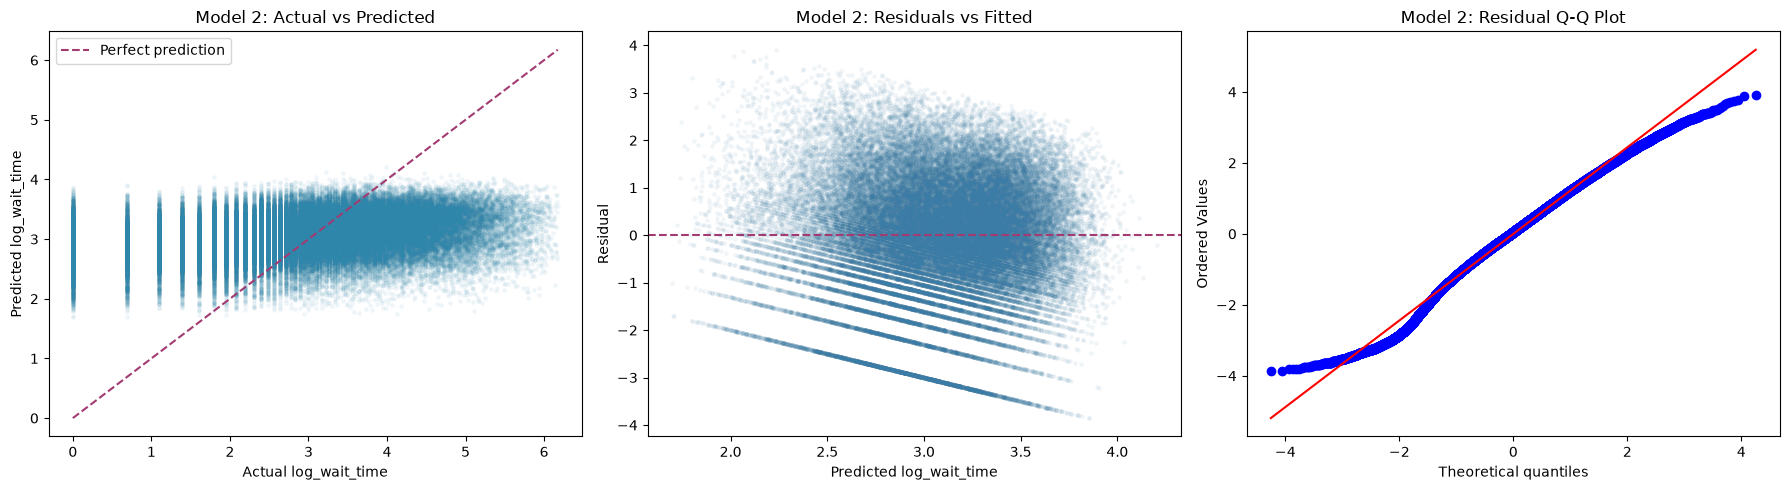

In [19]:
from scipy import stats

residuals2 = y_test - preds2

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, preds2, alpha=0.05, s=6, color="#2E86AB")
lims = [min(y_test.min(), preds2.min()), max(y_test.max(), preds2.max())]
axes[0].plot(lims, lims, color="#A23B72", linestyle="--", label="Perfect prediction")
axes[0].set_xlabel("Actual log_wait_time")
axes[0].set_ylabel("Predicted log_wait_time")
axes[0].set_title("Model 2: Actual vs Predicted")
axes[0].legend()

axes[1].scatter(preds2, residuals2, alpha=0.05, s=6, color="#3A7CA5")
axes[1].axhline(0, color="#A23B72", linestyle="--")
axes[1].set_xlabel("Predicted log_wait_time")
axes[1].set_ylabel("Residual")
axes[1].set_title("Model 2: Residuals vs Fitted")

stats.probplot(residuals2, dist="norm", plot=axes[2])
axes[2].set_title("Model 2: Residual Q-Q Plot")

plt.tight_layout()
plt.show()

**Findings — model evaluation diagnostics**

| Model | R² | MAE (log) | MAE (minutes) |
|---|---|---|---|
| Model 1 (demographic + access) | 0.074 | 0.968 | 31.5 |
| Model 2 (+ clinical) | 0.078 | 0.966 | 31.4 |

- **Actual vs. Predicted:** predictions are compressed into a narrow band (~1.7–4.2) while actual values span the full 0–6.2 range — the model consistently underpredicts long waits and overpredicts very short ones. This is the visual signature of a low-R² model: it captures the average level and direction of effects, not the spread.
- **Residuals vs. Fitted:** shows sharp diagonal edges rather than a random cloud — an upper boundary sloping down-right and a lower boundary sloping down-left. These are structural, not a modeling flaw: `log_wait_time` is bounded between 0 (wait_time=0) and log1p(480)≈6.18 (the 480-minute clamp from `preprocess.py`), which caps how large a residual can be at any given fitted value. The diagonal striping within the envelope reflects the target being discrete (integer minutes), not continuous.
- **Q-Q plot:** residuals track the 45° line reasonably well through the middle but flatten at both tails — the same bounded-target effect (residuals can't grow arbitrarily large at either the 0-minute or 480-minute clamp). Consistent with `MODELING.md`'s expectation of heteroskedasticity, which is exactly why the coefficient inference above uses HC3 robust standard errors rather than plain OLS SEs.
- None of this changes the equity conclusion: it explains *why* R² is low and standard errors need robustness correction, not that the demographic/payment coefficients are unreliable — HC3 already accounts for it.

### Equity comparison: Model 1 vs. Model 2 coefficients

Coefficients are on `log_wait_time`, so a value of 0.10 means that group's wait time is
~10% (≈ e^0.10 − 1) longer than the reference category, holding other features fixed.
A large negative `change` from Model 1 → Model 2 means clinical controls explain away
some of that group's disadvantage; a `change` near zero means clinical need does not
account for it.

In [20]:
coef1 = pd.Series(lr1.coef_, index=X1_train.columns)
coef2 = pd.Series(lr2.coef_, index=X2_train.columns)

# Columns present in both models (demographic + access features)
shared = coef1.index.intersection(coef2.index)
comparison = pd.DataFrame({
    "Model 1 (total effect)": coef1[shared],
    "Model 2 (residual effect)": coef2[shared],
})
comparison["change"] = comparison["Model 2 (residual effect)"] - comparison["Model 1 (total effect)"]
comparison.sort_values("Model 1 (total effect)")

,Model 1 (total effect),Model 2 (residual effect),change
arrival_mode_Ambulance,-0.485401,-0.461706,0.023695
survey_year,-0.271640,-0.271074,0.000566
arrival_mode_Public service (nonambulance),-0.077891,-0.081812,-0.003921
visit_day_of_week_Saturday,-0.074567,-0.074836,-0.000269
visit_month_August,-0.073517,-0.074917,-0.001400
visit_month_June,-0.062828,-0.064929,-0.002101
visit_day_of_week_Sunday,-0.061648,-0.061797,-0.000150
sex_Male,-0.058315,-0.050553,0.007762
race_Native Hawaiian/Oth Pac Isl Only,-0.055703,-0.062994,-0.007290
residence_Nursing home,-0.052107,-0.058541,-0.006434


**Findings — Model 1 vs. Model 2 coefficient shrinkage — the central result**

Demographic and payment coefficients barely move from Model 1 to Model 2, despite adding
triage acuity and vitals:

| Variable | Model 1 (total) | Model 2 (residual) | Change |
|---|---|---|---|
| `race_Black/African American Only` | +0.229 | +0.231 | +0.002 (no shrinkage) |
| `race_More than one race reported` | +0.236 | +0.228 | -0.009 (minimal) |
| `ethnicity_Hispanic or Latino` | +0.108 | +0.108 | ~0.000 (flat) |
| `payment_type_Medicaid/CHIP` | +0.068 | +0.068 | ~0.000 (flat) |
| `payment_type_Self-pay` | +0.128 | +0.124 | -0.003 (minimal) |
| `payment_type_No charge/Charity` | +0.161 | +0.168 | +0.006 (no shrinkage) |

None of the demographic or payment coefficients shrink meaningfully once triage acuity and
vitals are added — the largest `|change|` among them is 0.009, versus total effects as large
as 0.23. **Adding clinical controls does not explain away these disparities.** Race, ethnicity,
and payment type remain associated with wait time even after accounting for documented medical
urgency, which is the answer to this project's core research question.

For context, the single largest-magnitude coefficient in either model is
`arrival_mode_Ambulance` (-0.485 in Model 1, -0.462 in Model 2, both p<0.001) — ambulance
arrivals wait ~38% less time, which does look clinical (they arrive with documented acuity),
and even this changes only modestly with clinical controls added.

### Robust inference (HC3 standard errors)

`sklearn.LinearRegression` doesn't compute p-values or standard errors. `statsmodels` does, and
`HC3` robust standard errors correct for heteroskedasticity — near-certain here, since longer
waits tend to have higher variance.

In [21]:
import statsmodels.api as sm

X1_train_sm = sm.add_constant(X1_train)
ols1 = sm.OLS(y_train, X1_train_sm).fit(cov_type="HC3")

X2_train_sm = sm.add_constant(X2_train)
ols2 = sm.OLS(y_train, X2_train_sm).fit(cov_type="HC3")

print(ols1.summary())

                            OLS Regression Results                            
Dep. Variable:          log_wait_time   R-squared:                       0.079
Model:                            OLS   Adj. R-squared:                  0.079
Method:                 Least Squares   F-statistic:                     505.5
Date:                Sun, 19 Jul 2026   Prob (F-statistic):               0.00
Time:                        18:26:34   Log-Likelihood:            -4.2761e+05
No. Observations:              263399   AIC:                         8.553e+05
Df Residuals:                  263353   BIC:                         8.558e+05
Df Model:                          45                                         
Covariance Type:                  HC3                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [22]:
print(ols2.summary())

                            OLS Regression Results                            
Dep. Variable:          log_wait_time   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                  0.084
Method:                 Least Squares   F-statistic:                     450.3
Date:                Sun, 19 Jul 2026   Prob (F-statistic):               0.00
Time:                        18:26:34   Log-Likelihood:            -4.2691e+05
No. Observations:              263399   AIC:                         8.539e+05
Df Residuals:                  263344   BIC:                         8.545e+05
Df Model:                          54                                         
Covariance Type:                  HC3                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

### Equity variables: significance-annotated summary

Same coefficients as the comparison table above, with HC3 p-values and significance stars
from the `statsmodels` fits — the format used in `MODELING.md`'s "Answering the research
question" table.

In [23]:
def sig_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""


equity_vars = [c for c in shared if c.startswith(("race_", "ethnicity_", "payment_type_"))]

equity = pd.DataFrame({
    "Model 1 coef": ols1.params.reindex(equity_vars),
    "Model 1 p": ols1.pvalues.reindex(equity_vars),
    "Model 2 coef": ols2.params.reindex(equity_vars),
    "Model 2 p": ols2.pvalues.reindex(equity_vars),
})
equity["Model 1 sig"] = equity["Model 1 p"].apply(sig_stars)
equity["Model 2 sig"] = equity["Model 2 p"].apply(sig_stars)
equity[["Model 1 coef", "Model 1 sig", "Model 2 coef", "Model 2 sig"]].round(4).sort_values("Model 1 coef")

,Model 1 coef,Model 1 sig,Model 2 coef,Model 2 sig
race_Native Hawaiian/Oth Pac Isl Only,-0.0557,,-0.0630,
payment_type_Worker's compensation,-0.0050,,-0.0156,
race_Unknown,0.0170,*,0.0220,**
payment_type_Medicare,0.0250,**,0.0356,***
race_Asian Only,0.0274,,0.0228,
payment_type_Medicaid/CHIP,0.0684,***,0.0681,***
payment_type_Unknown,0.0837,***,0.0910,***
payment_type_Other,0.0963,***,0.0942,***
race_American Indian/Alaska Native Only,0.1030,***,0.1068,***
ethnicity_Hispanic or Latino,0.1081,***,0.1076,***


**Findings — significance of equity variables**

- Highly significant (p<0.001) in **both** models and persisting: `race_Black/African American 
  Only` (+0.229 → +0.231), `race_More than one race reported` (+0.236 → +0.228), 
  `race_American Indian/Alaska Native Only` (+0.103 → +0.107), `ethnicity_Hispanic or Latino` 
  (+0.108 → +0.108), `payment_type_Medicaid/CHIP`, `payment_type_Self-pay`, and 
  `payment_type_No charge/Charity` (+0.161 → +0.168, the largest payment effect).
- **Not statistically significant in either model:** `race_Native Hawaiian/Oth Pac Isl Only` 
  (coefficient is negative and small, but this is also the smallest race category from the 
  EDA at n=1,493 — likely a power issue) and `race_Asian Only` (coefficient near zero in both 
  models, +0.027 → +0.023 — consistent with the EDA's raw bivariate means for Asian patients 
  being close to White patients, so this reads as a genuinely small effect rather than a power 
  problem, since n=6,973 is not especially small).
- `payment_type_Worker's compensation` is also non-significant in either model (small group, 
  n=2,908, and the only payment category with a negative coefficient).
- `payment_type_Medicare` and `race_Unknown` go from `**` in Model 1 to `***` in Model 2 — a 
  minor precision gain from added clinical controls, not a substantive change in the estimate.

## Modeling summary

**Answering the research question:** demographic and access factors remain associated with ED
wait time after controlling for documented medical urgency — clinical need does **not** explain
away the disparities found in this data.

1. Adding clinical controls (triage acuity, vitals, prior-visit flag) improves R² by only 
   +0.004 (0.074 → 0.079) — clinical need barely adds predictive power beyond what demographics 
   and access variables already capture.
2. The core equity coefficients (race, ethnicity, payment type) are essentially unchanged 
   between Model 1 and Model 2 — the largest shrinkage among them is 0.009, against total 
   effects up to 0.23. If clinical need were the real driver of these gaps, adding triage acuity 
   and vitals should have shrunk them; it didn't.
3. The largest, most significant, and most persistent gaps: Black patients (+23–26% longer wait 
   vs. White), multiracial patients (+23–27%), Hispanic/Latino ethnicity (+11%), and — on the 
   access side — No charge/Charity (+18%) and Self-pay (+13–14%) patients vs. privately insured.
4. Small-n race categories (Native Hawaiian/Pacific Islander, and to a lesser extent Asian) 
   don't reach significance — treat as inconclusive rather than "no effect," given the sample 
   sizes flagged in the EDA.
5. `arrival_mode_Ambulance` is the single largest coefficient in either model (~38% shorter 
   wait) — plausibly clinical (ambulance patients arrive with documented acuity already known 
   to staff), but this is a hypothesis, not something this dataset can confirm directly.

**Caveats carried over from the EDA:** these are individual-level associations in the NHAMCS 
sample, not causal effects — hospital-level factors (staffing, bed availability) aren't 
recorded and R² reflects that. Survey weights aren't applied, so results describe this sample, 
not the nationally-weighted ED population. Next steps per `MODELING.md`: Lasso as a screening 
check, Random Forest to test for non-linear structure the EDA's non-monotonic triage finding 
hints at, and the pre/post-ACA robustness split.